# National Ground-Water Monitoring Network (NGWMN)

The [National Ground-Water Monitoring Network](https://cida.usgs.gov/ngwmn/) (NGWMN)
brings groundwater data from many state, federal, and local agencies into a single
location. USGS exposes it through a dedicated OGC API
(`https://api.waterdata.usgs.gov/ngwmn/ogcapi`), which `dataretrieval` wraps in the
`dataretrieval.ngwmn` module — a sibling of `dataretrieval.waterdata` built on the
same shared OGC engine, so chunking, pagination, and result shaping behave the same.

There are five getters:

| Function | Description |
| --- | --- |
| `get_sites` | Monitoring-location (well) metadata |
| `get_water_level` | Water-level observations |
| `get_lithology` | Lithology (geologic material) logs |
| `get_well_construction` | Well-construction records |
| `get_providers` | Contributing data providers |

Unlike the main Water Data collections, NGWMN aggregates locations from many
agencies, so `monitoring_location_id` values use agency prefixes besides `USGS-`
(e.g. `MBMG-702934`, `AKDNR-535134236016630`).

In [1]:
from dataretrieval import ngwmn

## Providers

List the organizations contributing data, optionally filtered by state.

In [2]:
providers, md = ngwmn.get_providers(state="WI")
print(f"{len(providers)} providers in WI")
providers.head()

Retrieving: providers · 1 page · 37 rows


No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


37 providers in WI


,id,agency_name,agency_code,organization_type,state,link
0,WI001,"WISCONSIN DEPARTMENT OF NATURAL RESOURCES, WI",WI001,NWIS,WI,
1,WI002,"EAST CENTRAL WISCONSIN REGIONAL PLANNING COM, WI",WI002,NWIS,WI,
2,WI003,"DAIRYLAND POWER COOPERATIVE, WI",WI003,NWIS,WI,
3,WI004,"NORTHERN STATES POWER COMPANY, WI",WI004,NWIS,WI,
4,WI005,"WISCONSIN STATE LABORATORY OF HYGIENE, WI",WI005,NWIS,WI,


## Sites

`get_sites` returns well metadata. Sites carry geometry by default, so the result is a
`GeoDataFrame`; pass `skip_geometry=True` to drop it.

In [3]:
sites, md = ngwmn.get_sites(state="Wisconsin")
print(f"{len(sites)} NGWMN sites in Wisconsin")
sites[["monitoring_location_id", "monitoring_location_name", "national_aquifer_description"]].head()

Retrieving: sites · 1 page · 175 rows

175 NGWMN sites in Wisconsin


,monitoring_location_id,monitoring_location_name,national_aquifer_description
0,USGS-423114090161101,LF-01/02E/33-0057,Cambrian-Ordovician aquifer system
1,USGS-423214087503801,KE-01/22E/13-0046,Silurian-Devonian aquifers
2,USGS-423312088350401,WW-01/16E/10-2194,Sand and gravel aquifers (glaciated regions)
3,USGS-423523088244901,2N18E-31.8a,Sand and gravel aquifers (glaciated regions)
4,USGS-423532088254601,WW-02/17E/36-0037,Cambrian-Ordovician aquifer system


## Water levels

`get_water_level` returns the observations for one or more sites. A two-element
`datetime=[start, end]` restricts the record to a time window; a list of
`monitoring_location_id`s fans out across sites and is unioned.

Retrieving: waterLevelObs · 1 page · 16,065 rows

16065 water-level observations at USGS-272838082142201


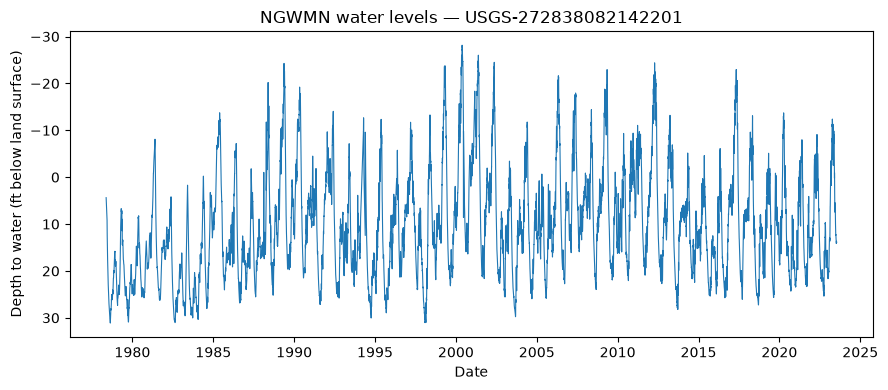

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

site = "USGS-272838082142201"
wl, md = ngwmn.get_water_level(monitoring_location_id=site)
print(f"{len(wl)} water-level observations at {site}")

wl["sample_time"] = pd.to_datetime(wl["sample_time"], errors="coerce", utc=True)
wl = wl.dropna(subset=["sample_time"]).sort_values("sample_time")
depth = pd.to_numeric(wl["water_depth_below_land_surface_ft"], errors="coerce")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(wl["sample_time"], depth, lw=0.8)
ax.invert_yaxis()  # depth increases downward
ax.set(xlabel="Date", ylabel="Depth to water (ft below land surface)",
       title=f"NGWMN water levels \u2014 {site}")
plt.tight_layout()
plt.show()

Restrict to a date range, or query several sites at once (they fan out and
union):

In [5]:
windowed, md = ngwmn.get_water_level(
    monitoring_location_id=site, datetime=["2022-01-01", "2024-01-01"]
)
print(f"{len(windowed)} observations in 2022\u20132024")

multi, md = ngwmn.get_water_level(
    monitoring_location_id=["USGS-272838082142201", "USGS-404159100494601"]
)
print(f"{multi['monitoring_location_id'].nunique()} sites, {len(multi)} observations")

Retrieving: waterLevelObs · 1 page · 559 rows

559 observations in 2022–2024


Retrieving: waterLevelObs · 1 page · 16,325 rows

2 sites, 16325 observations


## Well construction and lithology

Construction records describe a well's physical build-out; lithology logs describe the
geologic materials with depth.

In [6]:
construction, md = ngwmn.get_well_construction(monitoring_location_id=site)
construction[["monitoring_location_obs_number", "type", "material", "depth_from", "depth_to"]].head()

Retrieving: constructionObs · 1 page · 2 rows

,monitoring_location_obs_number,type,material,depth_from,depth_to
0,1,casing,NaN,0,208
1,2,screen,"Screen, Type Not Known",208,1123


In [7]:
lithology, md = ngwmn.get_lithology(monitoring_location_id="AKDNR-535134236016630")
lithology[["lithology_depth_from", "lithology_depth_to", "lithology_description"]].head()

Retrieving: lithologyObs · 1 page · 1 rows

,lithology_depth_from,lithology_depth_to,lithology_description
0,0,70,glacial alluvium
